In [ ]:
# ========================================================
#                       VISUALIZATION
# ========================================================

In [1]:
import pandas as pd

In [2]:

users = pd.read_csv(r"C:\Users\boyal\OneDrive\Python_Data_Analytics_Portfolio\Project_1_Ecommerce_Analysis\01_Data\users.csv")
reviews = pd.read_csv(r"C:\Users\boyal\OneDrive\Python_Data_Analytics_Portfolio\Project_1_Ecommerce_Analysis\01_Data\reviews.csv")
products = pd.read_csv(r"C:\Users\boyal\OneDrive\Python_Data_Analytics_Portfolio\Project_1_Ecommerce_Analysis\01_Data\products.csv")
orders = pd.read_csv(r"C:\Users\boyal\OneDrive\Python_Data_Analytics_Portfolio\Project_1_Ecommerce_Analysis\01_Data\orders.csv")
order_items = pd.read_csv(r"C:\Users\boyal\OneDrive\Python_Data_Analytics_Portfolio\Project_1_Ecommerce_Analysis\01_Data\order_items.csv")
events = pd.read_csv(r"C:\Users\boyal\OneDrive\Python_Data_Analytics_Portfolio\Project_1_Ecommerce_Analysis\01_Data\events.csv")

In [5]:
df1 = order_items.merge(orders, on="order_id")
df2 = df1.merge(products, on="product_id")
df2 = df2.rename(columns={"user_id_x":"user_id"})
df3 = df2.merge(users, on="user_id")
df = df3.merge(events, on="user_id")

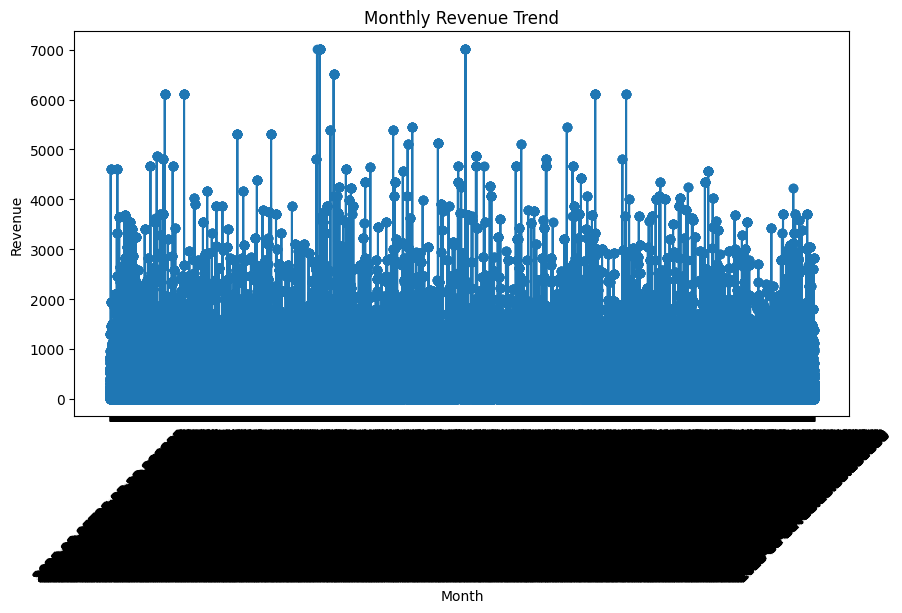

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['order_date'].astype(str), df["item_total"], marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [12]:
df["order_date"] = pd.to_datetime(df["order_date"])


In [18]:
month = df.groupby(df["order_date"].dt.to_period('M'))["item_total"].sum().reset_index(name="total revenue")

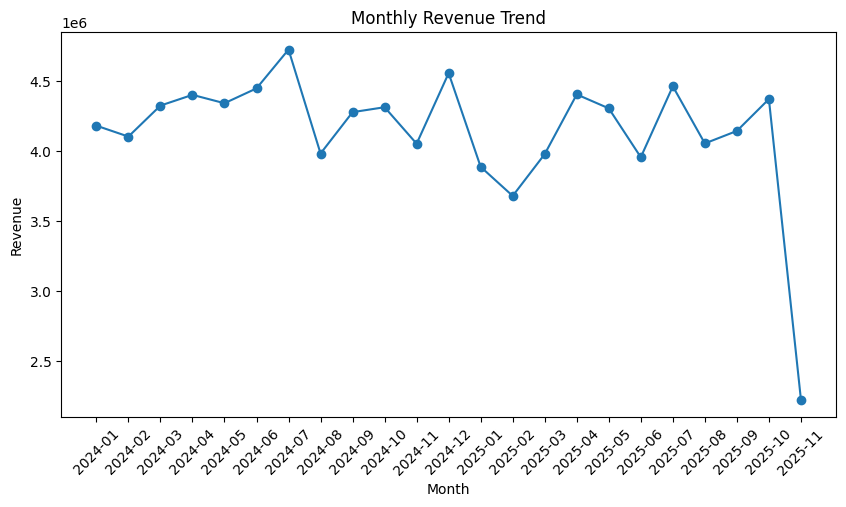

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(month['order_date'].astype(str), month["total revenue"], marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [35]:
category = df.groupby("category")["item_total"].sum().sort_values(ascending=False).reset_index(name="total revenue")

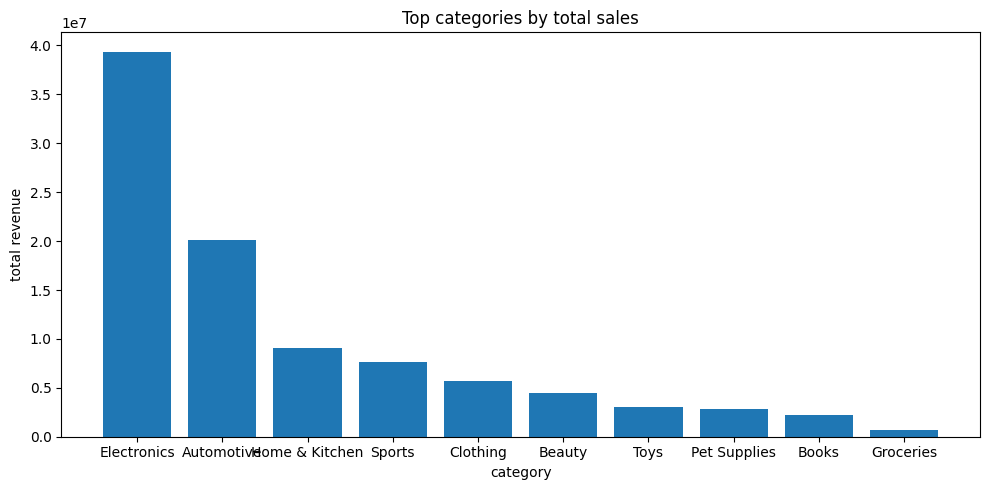

In [36]:
plt.figure(figsize=(10,5))

bars = plt.bar(category["category"], category["total revenue"])

plt.title('Top categories by total sales')
plt.xlabel('category')
plt.ylabel('total revenue')

plt.tight_layout()
plt.show()

In [20]:
gender_revenue = df.groupby("gender")["item_total"].sum()

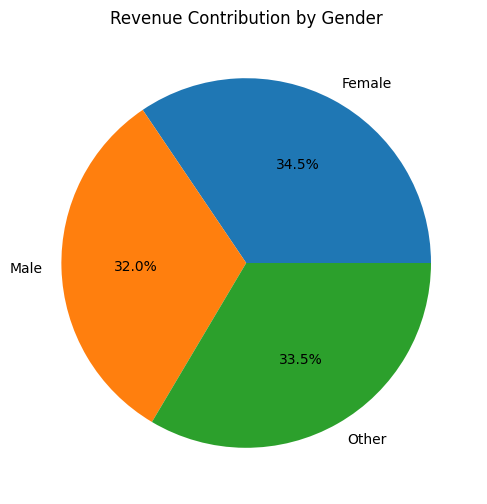

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    gender_revenue,
    labels=gender_revenue.index,
    autopct='%1.1f%%'
)

plt.title('Revenue Contribution by Gender')

plt.show()

In [26]:
top_cities = df.groupby("city")["order_id"].nunique().sort_values(ascending=False).reset_index(name="total_orders").head(10)

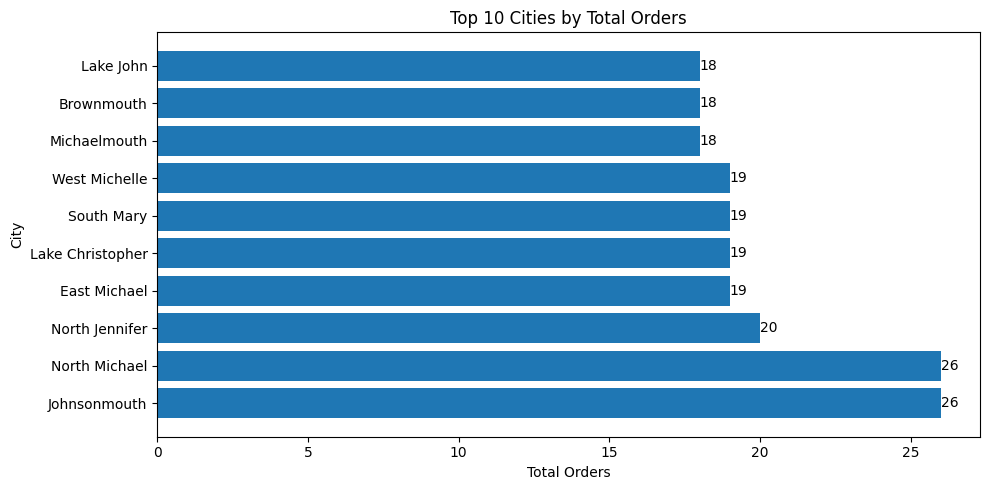

In [28]:
plt.figure(figsize=(10,5))

bars = plt.barh(top_cities['city'], top_cities['total_orders'])

plt.title('Top 10 Cities by Total Orders')
plt.xlabel('Total Orders')
plt.ylabel('City')

# ✅ Add labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             int(width), va='center')

plt.tight_layout()
plt.show()

In [30]:
top_products = df.groupby("product_name")["item_total"].sum().sort_values(ascending=False).reset_index().head()

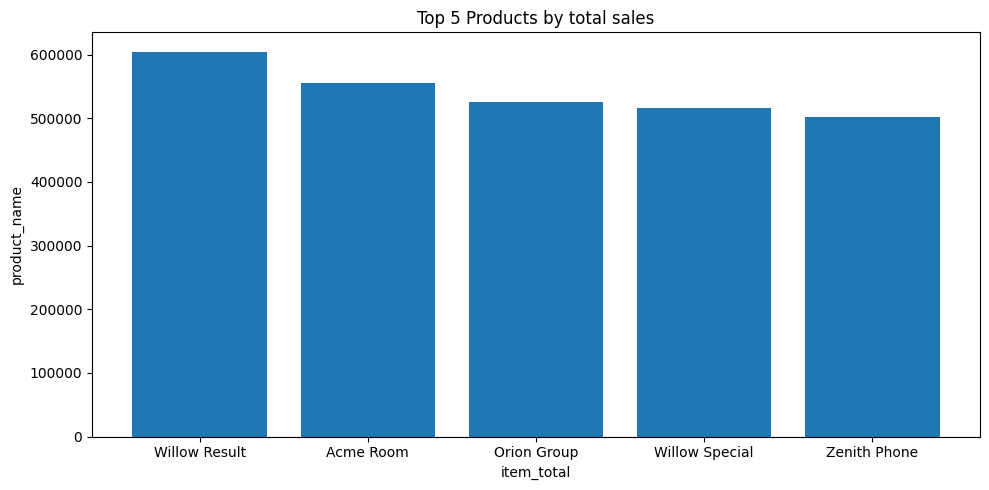

In [34]:
plt.figure(figsize=(10,5))

bars = plt.bar(top_products["product_name"], top_products["item_total"])

plt.title('Top 5 Products by total sales')
plt.xlabel('item_total')
plt.ylabel('product_name')

plt.tight_layout()
plt.show()